# Dual annealing instead

In [ ]:
from scipy.optimize import dual_annealing

# Your system parameters
natural_freq = 10  # GHz
driving_freq = 10
rabi_freq = 0.005  # GHz (5 MHz)

# Constants (not optimised)
phi_0, epsilon_m_const, phase_freq, theta_m_const = np.pi/2, rabi_freq/4, rabi_freq, np.pi/2

evaluation_points = 1000
evaluation_time = 4 / rabi_freq
tol = 1e-12

# Target root-X gate
root_x = (1 / np.sqrt(2)) * np.array([[1, -1j], [-1j, 1]])

# Objective function: 1 - fidelity
def objective(params):
    epsilon_m, phi, theta = params

    try:
        _, Us_driving_frame = qt.calculate_unitaries(
            1,
            evaluation_time,
            evaluation_points,
            hamiltonians.ccd_rwa,
            driving_freq=driving_freq,
            natural_freq=natural_freq,
            rabi_freq=rabi_freq,
            phi_0=phi * np.pi,
            epsilon_m=epsilon_m * rabi_freq,
            phase_freq=phase_freq,
            theta_m=theta * np.pi,
            rtol=tol,
            atol=tol
        )

        fid = qt.calculate_fidelities(root_x, Us_driving_frame, 2)
        return 1 - fid[-1]

    except Exception as e:
        print(f"Error during evaluation: {e}")
        return 1  # Penalise errors with high infidelity

# Bounds for dual_annealing: same format as L-BFGS-B
bounds = [(1/10, 1.0), (0, 2), (0, 2)]  # (εₘ, φ, θ)

# Run dual annealing optimisation
result = dual_annealing(objective, bounds)

# Extract optimal results
optimal_epsilon_m, optimal_phi, optimal_theta = result.x
optimal_fidelity = 1 - result.fun

print(f"✅ Optimal εₘ: {optimal_epsilon_m} *rabi_freq")
print(f"✅ Optimal φ: {optimal_phi}*pi ")
print(f"✅ Optimal θ: {optimal_theta}*pi")
print(f"🎯 Max Fidelity: {optimal_fidelity}")

KeyboardInterrupt: 

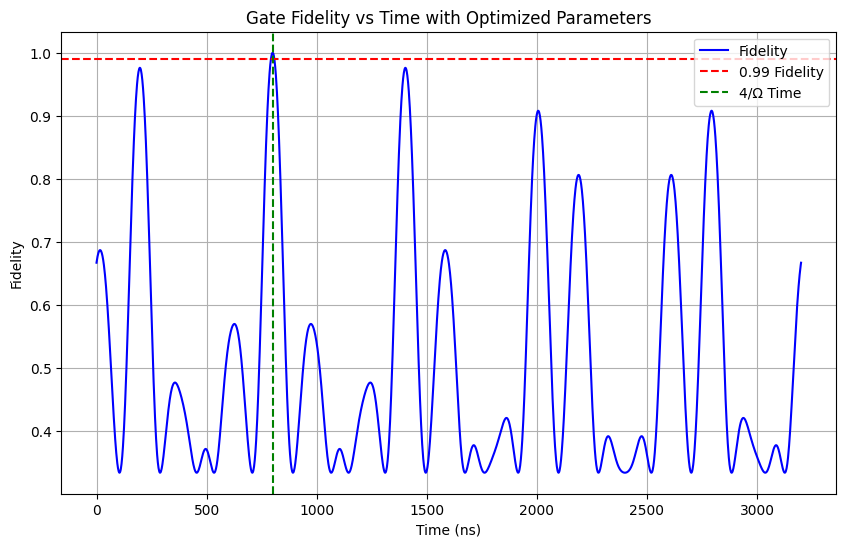

In [ ]:
# Use optimized parameters
natural_freq = 10  # 10GHz
driving_freq = 10
rabi_freq = 0.005  # 5MHz

# Use the optimized parameters from the optimization
epsilon_m = optimal_epsilon_m * rabi_freq
phi_0 = optimal_phi*np.pi
theta_m = optimal_theta*np.pi


# Integration parameters - run for 16 rabi periods
evaluation_points = 2000
evaluation_time = 16/rabi_freq  # 16 times the rabi period

# Calculate unitaries and fidelities
times, Us_driving_frame = qt.calculate_unitaries(1, evaluation_time, evaluation_points, 
                                               hamiltonians.ccd_rwa,
                                               driving_freq=driving_freq,
                                               natural_freq=natural_freq, 
                                               rabi_freq=rabi_freq, 
                                               phi_0=phi_0,
                                               epsilon_m=epsilon_m,
                                               phase_freq=phase_freq,
                                               theta_m=theta_m)

# Calculate fidelity with root-X gate
fidelities = qt.calculate_fidelities(root_x, Us_driving_frame, 2)

# Plot the results
plt.figure(figsize=(10, 6))
plt.plot(times, fidelities, 'b-', label='Fidelity')
plt.axhline(y=0.99, color='r', linestyle='--', label='0.99 Fidelity')
plt.axvline(x=4/rabi_freq, color='g', linestyle='--', label='4/Ω Time')

plt.xlabel('Time (ns)')
plt.ylabel('Fidelity')
plt.title('Gate Fidelity vs Time with Optimized Parameters')
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
def ccd_second_frame(epsilon_m, rabi_freq, theta_m, phi_0, t):
    """
    Second-order rotating-frame Hamiltonian H_rot^(2)(t).
    All frequencies should be in Hz.
    """
    epsilon_m = 2*np.pi*epsilon_m
    rabi_omega = 2*np.pi*rabi_freq

    cos_theta_m = np.cos(theta_m)
    sin_theta_m = np.sin(theta_m)
    cos_phi_mw = np.cos(phi_0)
    sin_phi_mw = np.sin(phi_0)

    cos_2omega_t = np.cos(2 * rabi_omega * t - theta_m)
    sin_2omega_t = np.sin(2 * rabi_omega * t - theta_m)

    H_static = (epsilon_m / 2) * (cos_theta_m * sigma_z + sin_theta_m * (-sin_phi_mw * sigma_x + cos_phi_mw * sigma_y))
    H_dynamic = (epsilon_m / 2) * (cos_2omega_t * sigma_z + sin_2omega_t * (-sin_phi_mw * sigma_x + cos_phi_mw * sigma_y))

    return H_static + H_dynamic

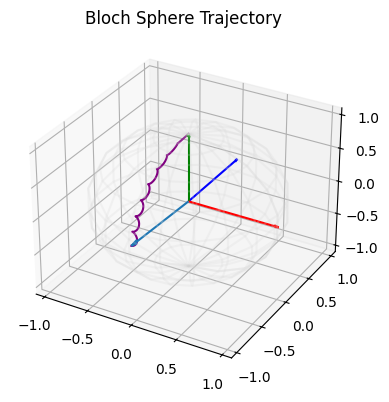

In [ ]:
# Create a quantum system with a single qubit
natural_freq = 10 # this is 10Ghz
driving_freq = 10
rabi_freq = 0.005 # this is 5Mhz

detuning = -rabi_freq/1024
driving_freq = natural_freq + detuning

# note that we are setting phase_freq to rabi_freq/16
# we are also setting theta_m to pi2
# as well as phi_0 
phi_0, epsilon_m, phase_freq, theta_m = -np.pi/2, rabi_freq/16, rabi_freq, np.pi/2

# Integration parameters
tol = 10**-12
evaluation_points = 4000
evaluation_time = 4/rabi_freq # 4*the rabi period in ns

times, Us_second_frame = qt.calculate_unitaries(1, evaluation_time, evaluation_points, 
                                               ccd_second_frame,
                                               rabi_freq=rabi_freq,
                                               phi_0=phi_0,
                                               epsilon_m=epsilon_m,
                                               theta_m=theta_m,
                                               atol=tol,
                                               rtol=tol)

initial_state = np.array([1+0j, 0+0j])

states = []
for U in Us_second_frame:
    state = U @ initial_state
    states.append(state)

states = np.array(states)
qt.visualise_solution(times, states)

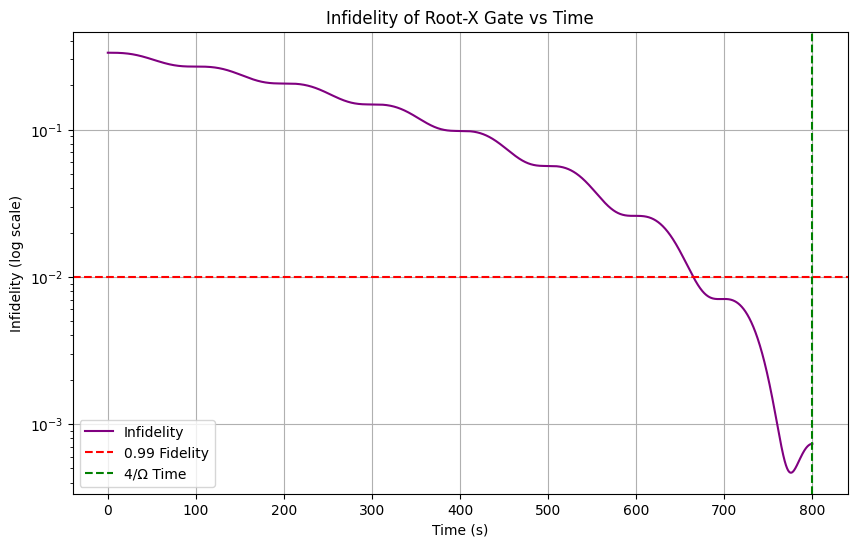

In [ ]:

# Calculate fidelity with respect to root-X gate
fidelities = qt.calculate_fidelities(root_x, Us_second_frame, 2)
# Plot fidelity against time
plt.figure(figsize=(10, 6))
plt.semilogy(times, 1-fidelities, label='Infidelity', color='purple')
plt.axhline(y=0.01, color='r', linestyle='--', label='0.99 Fidelity')
plt.axvline(x=4/rabi_freq, color='g', linestyle='--', label='4/Ω Time')
plt.xlabel('Time (s)')
plt.ylabel('Infidelity (log scale)')
plt.title('Infidelity of Root-X Gate vs Time')
plt.legend()
plt.grid()
plt.show()

